In [1]:
import pandas as pd
import numpy as np
import os, re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    confusion_matrix,
    accuracy_score,
    f1_score,
    recall_score
)

In [2]:
def get_street_score(text):
    keywords = ['street', 'block', 'gang', 'money', 'hustle', 'choppa', 'glock', 'пацан', 'район', 'брат']
    if not isinstance(text, str): return 0
    text = text.lower()
    return sum(1 for word in keywords if word in text)

In [3]:
data_path='data/processed/featured_data_1.csv'
df = pd.read_csv(data_path).dropna(subset=['target'])

In [4]:
df['clean_lyrics'] = df['clean_lyrics'].fillna('').astype(str)
df['street_score'] = df['clean_lyrics'].apply(get_street_score)
df['is_trap_bpm'] = df['bpm'].apply(lambda x: 1 if (60 <= x <= 78) or (135 <= x <= 160) else 0)
df['is_lofi_bpm'] = df['bpm'].apply(lambda x: 1 if x < 85 else 0)
duration = df['itunes_duration_ms'].fillna(210000).replace(0, 210000) / 1000
df['word_density'] = df['lyrics_word_count'].fillna(0) / duration
df['power_index'] = (df['bpm'] * (df['gain'].fillna(-10) + 25)) / 100
genre_col = 'genre_final' if 'genre_final' in df.columns else 'itunes_genre'
df['text_combined'] = (
            df['track_name'].fillna('').astype(str) + " " + df['artist_name'].fillna('').astype(str) + " " + df[
        genre_col].fillna('').astype(str)).str.lower()

num_features = ['bpm', 'gain', 'street_score', 'is_trap_bpm', 'is_lofi_bpm', 'word_density', 'power_index']

In [5]:
X = df[num_features + ['text_combined']]
y = df['target']

X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.25, random_state=42, stratify=y_dev
)

In [6]:
print(f"Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

Train=399, Val=133, Test=133


In [7]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('text', TfidfVectorizer(max_features=250), 'text_combined')
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=3, class_weight='balanced', random_state=42
    ))
])

In [8]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(pipeline, X_dev, y_dev, cv=skf, scoring='balanced_accuracy')
cv_mean = cv_results['test_score'].mean()

pipeline.fit(X_train, y_train)
val_bal_acc = balanced_accuracy_score(y_val, pipeline.predict(X_val))

pipeline.fit(X_dev, y_dev)
y_test_pred = pipeline.predict(X_test)

In [9]:
acc = accuracy_score(y_test, y_test_pred)
f1_macro = f1_score(y_test, y_test_pred, average='macro')
rec_macro = recall_score(y_test, y_test_pred, average='macro')
test_bal_acc = balanced_accuracy_score(y_test, y_test_pred)

In [10]:
print(f"1. Среднее по Кросс-валидации:      {cv_mean:.4f}")
print(f"2. Фиксированная Валидация (Val):   {val_bal_acc:.4f}")
print(f"Balanced Accuracy:       {test_bal_acc:.4f}")
print(f"Accuracy (Test):                   {acc:.4f}")
print(f"F1-Score Macro (Test):             {f1_macro:.4f}")
print(f"Recall Macro (Test):               {rec_macro:.4f}")
print(classification_report(y_test, y_test_pred, zero_division=0))

1. Среднее по Кросс-валидации:      0.7086
2. Фиксированная Валидация (Val):   0.7124
Balanced Accuracy:       0.7501
Accuracy (Test):                   0.7895
F1-Score Macro (Test):             0.7508
Recall Macro (Test):               0.7501
                          precision    recall  f1-score   support

Boss Fight / Doom Slayer       1.00      0.79      0.88        14
 Golden Era (Old School)       0.76      0.81      0.79        27
            Pilates Girl       0.75      0.80      0.77        15
   Pure Rage / Metalhead       0.87      0.83      0.85        41
          Sigma Grindset       0.50      0.50      0.50         8
    Zen / Lo-Fi Recovery       0.64      0.58      0.61        12
          Пацанский Вайб       0.79      0.94      0.86        16

                accuracy                           0.79       133
               macro avg       0.76      0.75      0.75       133
            weighted avg       0.80      0.79      0.79       133



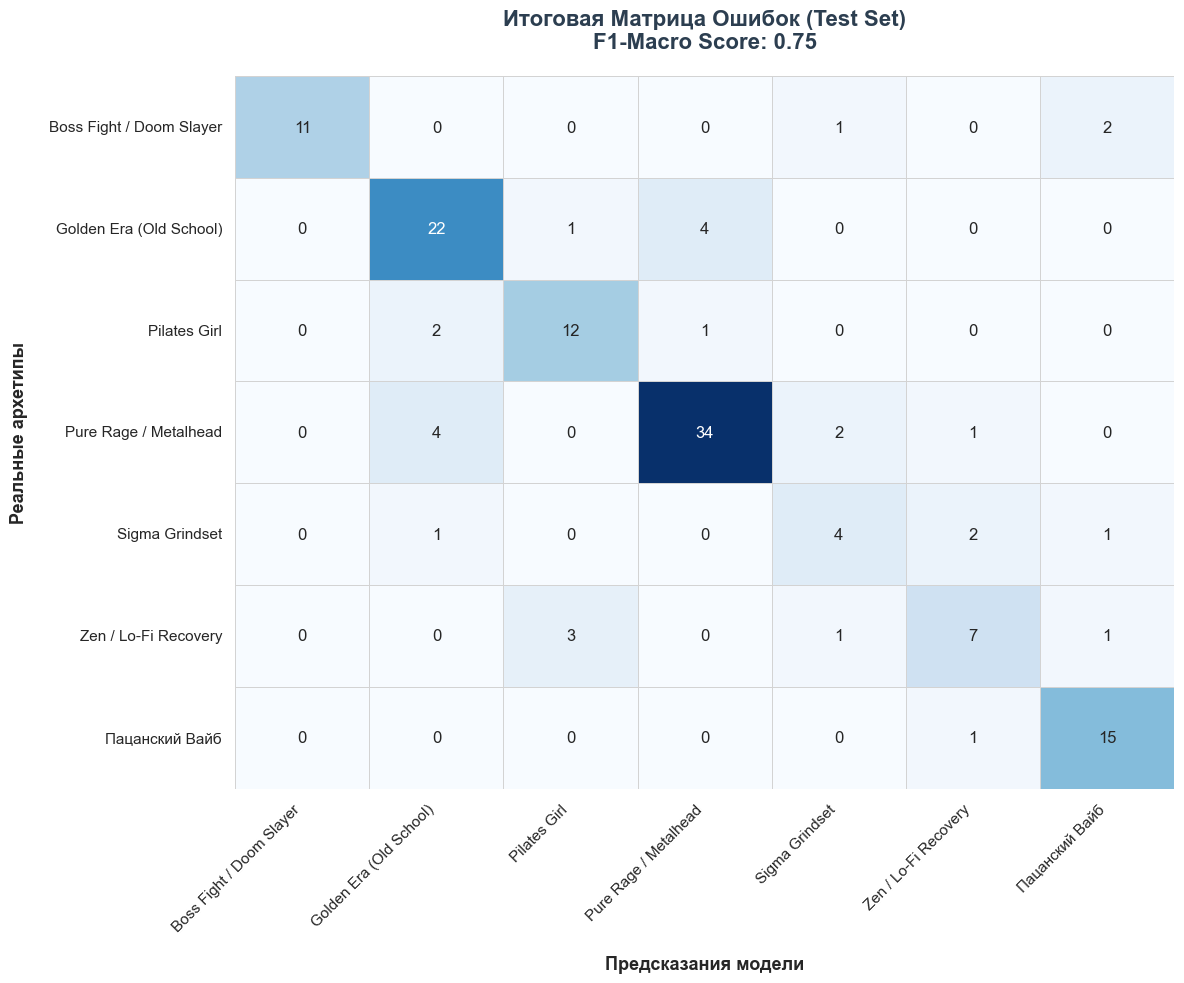

In [11]:
sns.set_theme(style="white")
classes = pipeline.named_steps['classifier'].classes_
cm = confusion_matrix(y_test, y_test_pred, labels=classes)

plt.figure(figsize=(12, 10))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor='lightgrey', cbar=False)

plt.title(f'Итоговая Матрица Ошибок (Test Set)\nF1-Macro Score: {f1_macro:.2f}',
          fontsize=16, pad=20, fontweight='bold', color='#2c3e50')

plt.ylabel('Реальные архетипы', fontsize=13, fontweight='bold', labelpad=15)
plt.xlabel('Предсказания модели', fontsize=13, fontweight='bold', labelpad=15)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.savefig('ultimate_matrix_pastel.png', dpi=300, bbox_inches='tight')
plt.show()